In [1]:
from pathlib import Path

data_path = Path("../data/raw/LSWMD.pkl")

print("파일 존재 여부:", data_path.exists())
print("파일 경로:", data_path)

파일 존재 여부: True
파일 경로: ../data/raw/LSWMD.pkl


In [2]:
import pandas as pd

df = pd.read_pickle("../data/raw/LSWMD.pkl")

print("데이터 타입:", type(df))
print("데이터 크기:", df.shape)
print("컬럼 목록:")
print(df.columns)

데이터 타입: <class 'pandas.core.frame.DataFrame'>
데이터 크기: (811457, 6)
컬럼 목록:
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [3]:
sample_df = df.sample(10000, random_state=42)

print("sample failureType 분포:")
print(sample_df["failureType"].astype(str).value_counts())

print("\nsample trianTestLabel 분포:")
print(sample_df["trianTestLabel"].astype(str).value_counts())

sample failureType 분포:
failureType
[]                 7889
[['none']]         1806
[['Edge-Ring']]      97
[['Center']]         57
[['Edge-Loc']]       56
[['Loc']]            52
[['Random']]         21
[['Scratch']]        14
[['Donut']]           8
Name: count, dtype: int64

sample trianTestLabel 분포:
trianTestLabel
[]                7889
[['Test']]        1450
[['Training']]     661
Name: count, dtype: int64


In [4]:
import numpy as np

df_labeled = df[df["failureType"].astype(str) != "[]"].copy()

def extract_label(value):
    return value[0][0]

df_labeled["failure_label"] = df_labeled["failureType"].apply(extract_label)
df_labeled["set_label"] = df_labeled["trianTestLabel"].apply(extract_label)

print("라벨 있는 데이터 크기:", df_labeled.shape)

print("\nfailure_label 분포:")
print(df_labeled["failure_label"].value_counts())

print("\nset_label 분포:")
print(df_labeled["set_label"].value_counts())

라벨 있는 데이터 크기: (172950, 8)

failure_label 분포:
failure_label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

set_label 분포:
set_label
Test        118595
Training     54355
Name: count, dtype: int64


In [5]:
df_labeled["map_shape"] = df_labeled["waferMap"].apply(lambda x: np.array(x).shape)

print("waferMap 크기 종류 수:", df_labeled["map_shape"].nunique())

print("\n가장 많은 waferMap 크기 상위 10개:")
print(df_labeled["map_shape"].value_counts().head(10))

waferMap 크기 종류 수: 346

가장 많은 waferMap 크기 상위 10개:
map_shape
(25, 27)    18781
(26, 26)    14366
(30, 34)    12400
(29, 26)    11751
(27, 25)    10682
(39, 37)    10173
(33, 29)     8125
(42, 44)     6724
(44, 41)     6134
(41, 33)     5091
Name: count, dtype: int64


In [6]:
df_labeled = df[df["failureType"].astype(str) != "[]"].copy()
df_unlabeled = df[df["failureType"].astype(str) == "[]"].copy()

print("전체 wafer 수:", len(df))
print("라벨 있는 wafer 수:", len(df_labeled))
print("라벨 없는 wafer 수:", len(df_unlabeled))

print("\n라벨 있는 wafer 비율:", len(df_labeled) / len(df))
print("라벨 없는 wafer 비율:", len(df_unlabeled) / len(df))

전체 wafer 수: 811457
라벨 있는 wafer 수: 172950
라벨 없는 wafer 수: 638507

라벨 있는 wafer 비율: 0.21313513839920045
라벨 없는 wafer 비율: 0.7868648616007996


In [7]:
def extract_label(value):
    return value[0][0]

df_labeled["failure_label"] = df_labeled["failureType"].apply(extract_label)
df_labeled["set_label"] = df_labeled["trianTestLabel"].apply(extract_label)

df_labeled["binary_label"] = df_labeled["failure_label"].apply(
    lambda x: "normal" if x == "none" else "defect"
)

print("failure_label 분포:")
print(df_labeled["failure_label"].value_counts())

print("\nbinary_label 분포:")
print(df_labeled["binary_label"].value_counts())

print("\nset_label 분포:")
print(df_labeled["set_label"].value_counts())

failure_label 분포:
failure_label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

binary_label 분포:
binary_label
normal    147431
defect     25519
Name: count, dtype: int64

set_label 분포:
set_label
Test        118595
Training     54355
Name: count, dtype: int64


In [8]:
label_summary = pd.DataFrame({
    "count": df_labeled["failure_label"].value_counts(),
    "ratio": df_labeled["failure_label"].value_counts(normalize=True)
})

print("failure label 요약:")
display(label_summary)

binary_summary = pd.DataFrame({
    "count": df_labeled["binary_label"].value_counts(),
    "ratio": df_labeled["binary_label"].value_counts(normalize=True)
})

print("binary label 요약:")
display(binary_summary)

failure label 요약:


,count,ratio
failure_label,,
none,147431,0.852449
Edge-Ring,9680,0.055970
Edge-Loc,5189,0.030003
Center,4294,0.024828
Loc,3593,0.020775
Scratch,1193,0.006898
Random,866,0.005007
Donut,555,0.003209
Near-full,149,0.000862


binary label 요약:


,count,ratio
binary_label,,
normal,147431,0.852449
defect,25519,0.147551


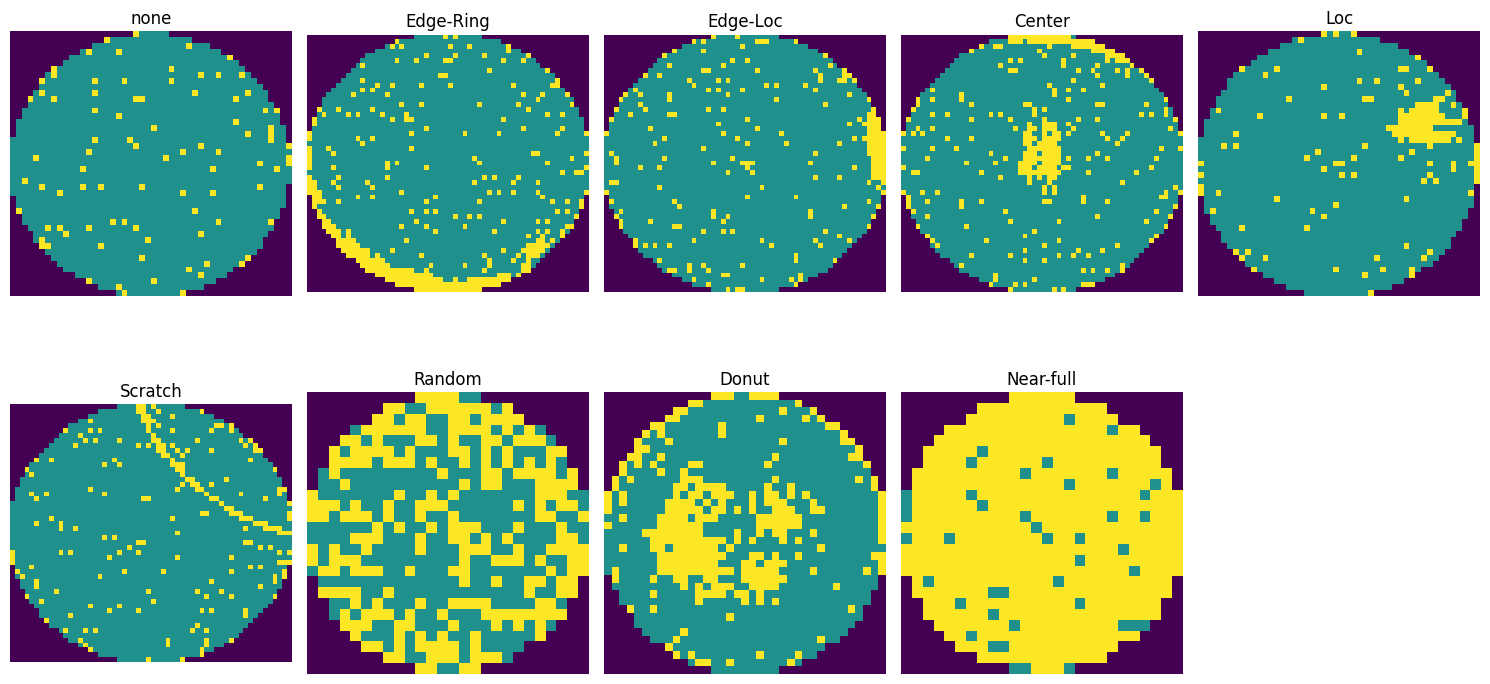

In [9]:
import matplotlib.pyplot as plt
import numpy as np

labels = df_labeled["failure_label"].value_counts().index.tolist()

plt.figure(figsize=(15, 8))

for i, label in enumerate(labels):
    sample = df_labeled[df_labeled["failure_label"] == label].iloc[0]
    wafer_map = np.array(sample["waferMap"])

    plt.subplot(2, 5, i + 1)
    plt.imshow(wafer_map, cmap="viridis")
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
for label in labels:
    sample = df_labeled[df_labeled["failure_label"] == label].iloc[0]
    wafer_map = np.array(sample["waferMap"])
    print(label, "unique values:", np.unique(wafer_map))

none unique values: [0 1 2]
Edge-Ring unique values: [0 1 2]
Edge-Loc unique values: [0 1 2]
Center unique values: [0 1 2]
Loc unique values: [0 1 2]
Scratch unique values: [0 1 2]
Random unique values: [0 1 2]
Donut unique values: [0 1 2]
Near-full unique values: [0 1 2]


In [11]:
def calculate_defect_ratio(wafer_map):
    wafer_map = np.array(wafer_map)
    
    valid_die_count = np.sum(wafer_map != 0)
    defect_die_count = np.sum(wafer_map == 2)
    
    if valid_die_count == 0:
        return 0
    
    return defect_die_count / valid_die_count

df_labeled["defect_ratio"] = df_labeled["waferMap"].apply(calculate_defect_ratio)

print("defect_ratio 요약:")
print(df_labeled["defect_ratio"].describe())

print("\nfailure_label별 평균 defect_ratio:")
print(df_labeled.groupby("failure_label")["defect_ratio"].mean().sort_values(ascending=False))

defect_ratio 요약:
count    172950.000000
mean          0.117627
std           0.073514
min           0.000000
25%           0.069257
50%           0.105670
75%           0.151046
max           1.000000
Name: defect_ratio, dtype: float64

failure_label별 평균 defect_ratio:
failure_label
Near-full    0.876908
Random       0.480617
Donut        0.276837
Center       0.232497
Edge-Loc     0.182849
Edge-Ring    0.151307
Loc          0.149954
none         0.105625
Scratch      0.100583
Name: defect_ratio, dtype: float64


In [12]:
def has_defect_die(wafer_map):
    wafer_map = np.array(wafer_map)
    return np.any(wafer_map == 2)

df_labeled["has_defect_die"] = df_labeled["waferMap"].apply(has_defect_die)

print("failure_label별 defect die 포함 비율:")
print(df_labeled.groupby("failure_label")["has_defect_die"].mean().sort_values(ascending=False))

failure_label별 defect die 포함 비율:
failure_label
Center       1.000000
Donut        1.000000
Edge-Loc     1.000000
Edge-Ring    1.000000
Loc          1.000000
Near-full    1.000000
Random       1.000000
Scratch      1.000000
none         0.999993
Name: has_defect_die, dtype: float64


In [13]:
df_labeled["pattern_label"] = df_labeled["failure_label"].apply(
    lambda x: "non_pattern" if x == "none" else "pattern"
)

print("pattern_label 분포:")
print(df_labeled["pattern_label"].value_counts())

print("\npattern_label 비율:")
print(df_labeled["pattern_label"].value_counts(normalize=True))

print("\npattern_label별 평균 defect_ratio:")
print(df_labeled.groupby("pattern_label")["defect_ratio"].mean())

pattern_label 분포:
pattern_label
non_pattern    147431
pattern         25519
Name: count, dtype: int64

pattern_label 비율:
pattern_label
non_pattern    0.852449
pattern        0.147551
Name: proportion, dtype: float64

pattern_label별 평균 defect_ratio:
pattern_label
non_pattern    0.105625
pattern        0.186962
Name: defect_ratio, dtype: float64


<Figure size 800x500 with 0 Axes>

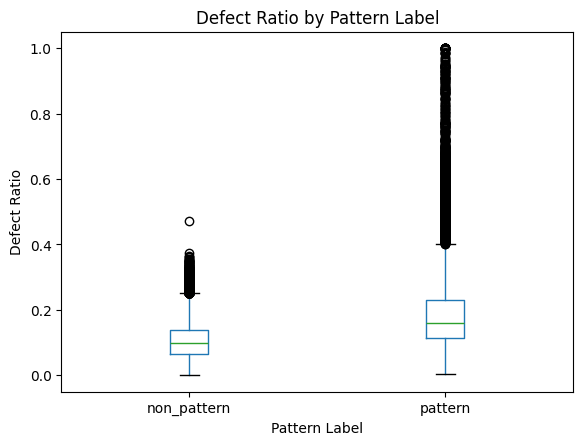

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df_labeled.boxplot(
    column="defect_ratio",
    by="pattern_label",
    grid=False
)

plt.title("Defect Ratio by Pattern Label")
plt.suptitle("")
plt.xlabel("Pattern Label")
plt.ylabel("Defect Ratio")
plt.show()

<Figure size 1200x500 with 0 Axes>

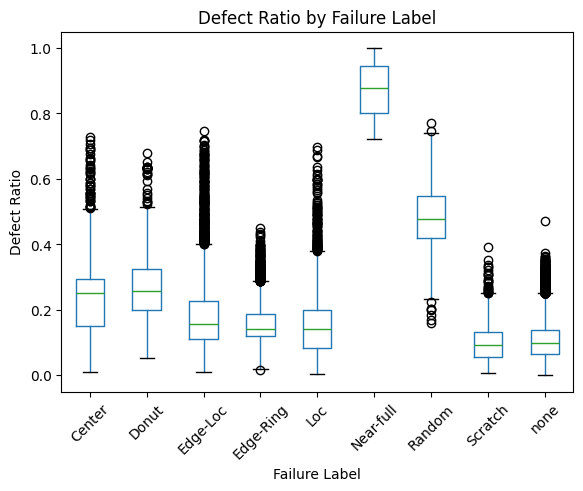

In [15]:
plt.figure(figsize=(12, 5))

df_labeled.boxplot(
    column="defect_ratio",
    by="failure_label",
    grid=False,
    rot=45
)

plt.title("Defect Ratio by Failure Label")
plt.suptitle("")
plt.xlabel("Failure Label")
plt.ylabel("Defect Ratio")
plt.show()

In [16]:
defect_ratio_summary = df_labeled.groupby("failure_label")["defect_ratio"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
).sort_values("mean", ascending=False)

display(defect_ratio_summary)

,count,mean,median,std,min,max
failure_label,,,,,,
Near-full,149,0.876908,0.877907,0.083538,0.722326,1.000000
Random,866,0.480617,0.476781,0.108275,0.158186,0.770533
Donut,555,0.276837,0.257562,0.111649,0.053597,0.678411
Center,4294,0.232497,0.250485,0.102873,0.009023,0.727142
Edge-Loc,5189,0.182849,0.155722,0.108689,0.010891,0.746124
Edge-Ring,9680,0.151307,0.140316,0.052971,0.016907,0.451005
Loc,3593,0.149954,0.142471,0.097227,0.005150,0.697624
none,147431,0.105625,0.098287,0.053070,0.000000,0.470588
Scratch,1193,0.100583,0.091667,0.060840,0.007067,0.392958


In [18]:
import sys

!{sys.executable} -m pip install scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 9.7 MB/s eta 0:00:0000:01m00:01
  Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.0/318.0 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 8.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [19]:
from skimage.transform import resize

sample_map = np.array(df_labeled.iloc[0]["waferMap"])

resized_map = resize(
    sample_map,
    (32, 32),
    order=0,
    preserve_range=True,
    anti_aliasing=False
).astype(int)

print("원본 shape:", sample_map.shape)
print("resize 후 shape:", resized_map.shape)
print("resize 후 unique values:", np.unique(resized_map))

원본 shape: (45, 48)
resize 후 shape: (32, 32)
resize 후 unique values: [0 1 2]


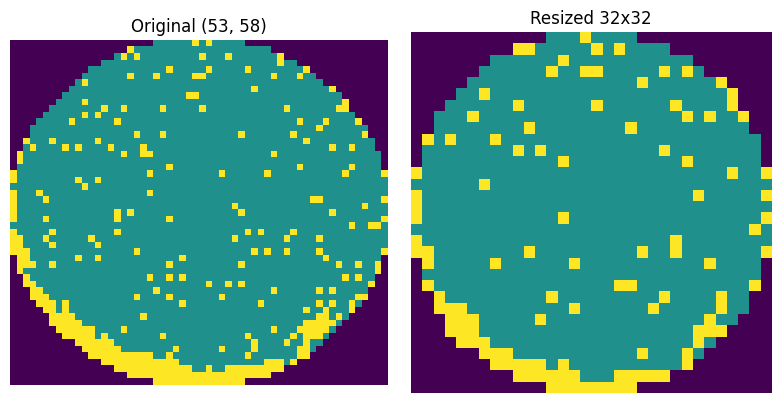

In [20]:
sample = df_labeled[df_labeled["failure_label"] == "Edge-Ring"].iloc[0]
original_map = np.array(sample["waferMap"])

resized_map = resize(
    original_map,
    (32, 32),
    order=0,
    preserve_range=True,
    anti_aliasing=False
).astype(int)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_map, cmap="viridis")
plt.title(f"Original {original_map.shape}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_map, cmap="viridis")
plt.title("Resized 32x32")
plt.axis("off")

plt.tight_layout()
plt.show()

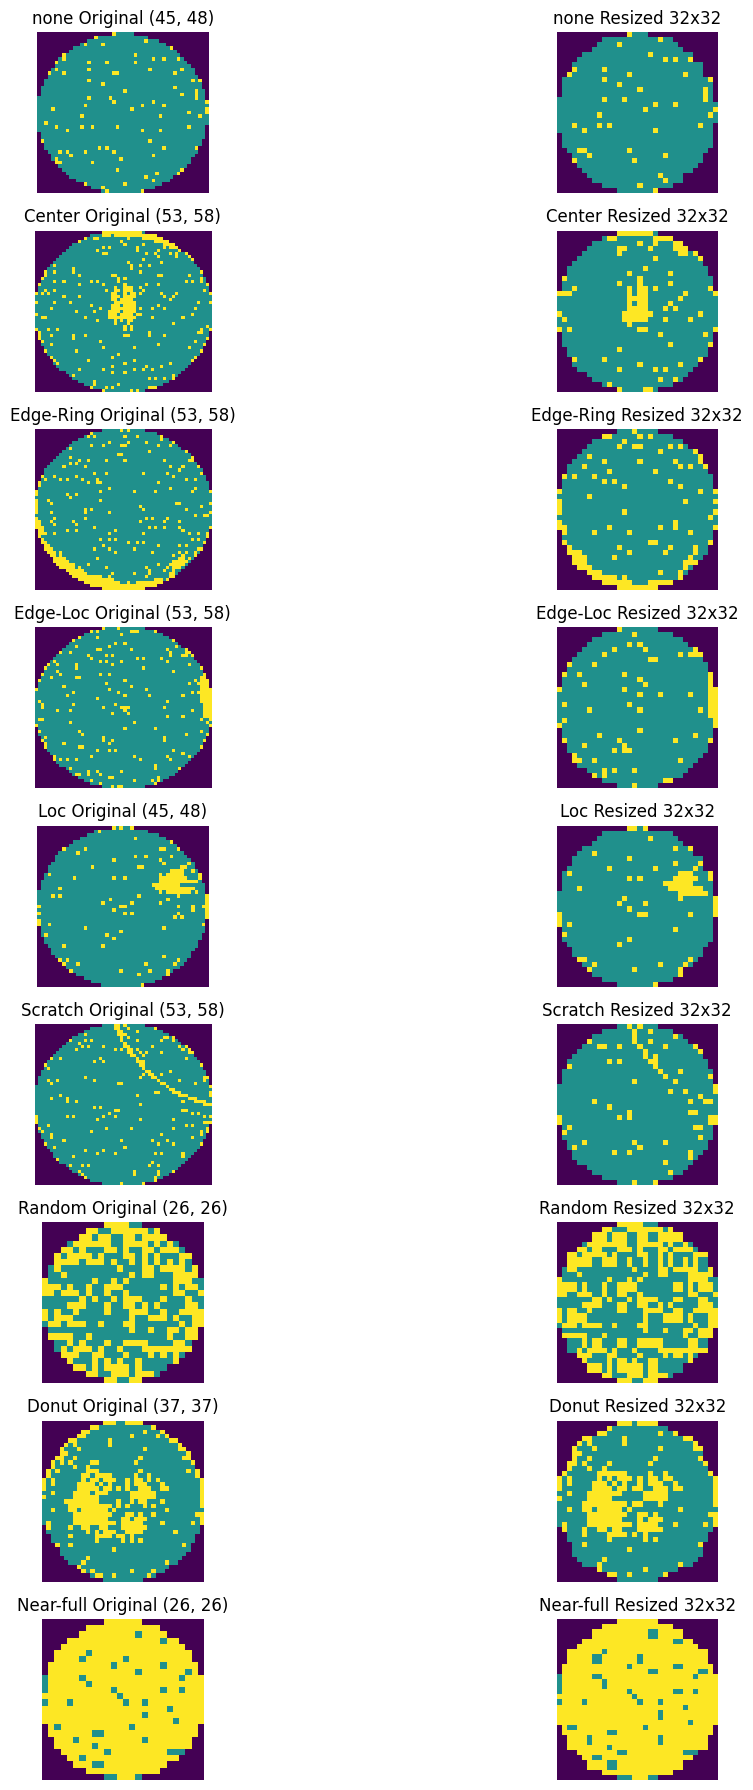

In [21]:
target_labels = ["none", "Center", "Edge-Ring", "Edge-Loc", "Loc", "Scratch", "Random", "Donut", "Near-full"]

plt.figure(figsize=(14, 18))

for i, label in enumerate(target_labels):
    sample = df_labeled[df_labeled["failure_label"] == label].iloc[0]
    original_map = np.array(sample["waferMap"])

    resized_map = resize(
        original_map,
        (32, 32),
        order=0,
        preserve_range=True,
        anti_aliasing=False
    ).astype(int)

    plt.subplot(len(target_labels), 2, 2 * i + 1)
    plt.imshow(original_map, cmap="viridis")
    plt.title(f"{label} Original {original_map.shape}")
    plt.axis("off")

    plt.subplot(len(target_labels), 2, 2 * i + 2)
    plt.imshow(resized_map, cmap="viridis")
    plt.title(f"{label} Resized 32x32")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
def resize_wafer_map(wafer_map, target_size=(32, 32)):
    wafer_map = np.array(wafer_map)

    resized = resize(
        wafer_map,
        target_size,
        order=0,
        preserve_range=True,
        anti_aliasing=False
    ).astype(int)

    return resized

sample_resized_maps = df_labeled["waferMap"].head(5).apply(resize_wafer_map)

print("샘플 resize 결과:")
for i, wafer_map in enumerate(sample_resized_maps):
    print(i, wafer_map.shape, np.unique(wafer_map))

샘플 resize 결과:
0 (32, 32) [0 1 2]
1 (32, 32) [0 1 2]
2 (32, 32) [0 1 2]
3 (32, 32) [0 1 2]
4 (32, 32) [0 1 2]


In [23]:
resized_maps = df_labeled["waferMap"].apply(resize_wafer_map)

print("resize 완료")
print("resize된 wafer 수:", len(resized_maps))
print("첫 번째 resize map shape:", resized_maps.iloc[0].shape)
print("첫 번째 resize map unique values:", np.unique(resized_maps.iloc[0]))

resize 완료
resize된 wafer 수: 172950
첫 번째 resize map shape: (32, 32)
첫 번째 resize map unique values: [0 1 2]


In [24]:
X = np.stack(resized_maps.values)
X = X[..., np.newaxis]

y_pattern = df_labeled["pattern_label"].values

print("X shape:", X.shape)
print("y_pattern shape:", y_pattern.shape)

print("\ny_pattern 분포:")
print(pd.Series(y_pattern).value_counts())

X shape: (172950, 32, 32, 1)
y_pattern shape: (172950,)

y_pattern 분포:
non_pattern    147431
pattern         25519
Name: count, dtype: int64


In [25]:
X_normalized = X / 2.0

print("X_normalized min:", X_normalized.min())
print("X_normalized max:", X_normalized.max())
print("X_normalized shape:", X_normalized.shape)

X_normalized min: 0.0
X_normalized max: 1.0
X_normalized shape: (172950, 32, 32, 1)


In [26]:
train_mask = df_labeled["set_label"] == "Training"
test_mask = df_labeled["set_label"] == "Test"

X_train = X_normalized[train_mask.values]
X_test = X_normalized[test_mask.values]

y_train_pattern = y_pattern[train_mask.values]
y_test_pattern = y_pattern[test_mask.values]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train_pattern 분포:")
print(pd.Series(y_train_pattern).value_counts())

print("\ny_test_pattern 분포:")
print(pd.Series(y_test_pattern).value_counts())

X_train shape: (54355, 32, 32, 1)
X_test shape: (118595, 32, 32, 1)

y_train_pattern 분포:
non_pattern    36730
pattern        17625
Name: count, dtype: int64

y_test_pattern 분포:
non_pattern    110701
pattern          7894
Name: count, dtype: int64


In [28]:
from sklearn.preprocessing import LabelEncoder

pattern_encoder = LabelEncoder()

y_train_encoded = pattern_encoder.fit_transform(y_train_pattern)
y_test_encoded = pattern_encoder.transform(y_test_pattern)

print("label classes:", pattern_encoder.classes_)

print("\ny_train_encoded 분포:")
print(pd.Series(y_train_encoded).value_counts())

print("\ny_test_encoded 분포:")
print(pd.Series(y_test_encoded).value_counts())

label classes: ['non_pattern' 'pattern']

y_train_encoded 분포:
0    36730
1    17625
Name: count, dtype: int64

y_test_encoded 분포:
0    110701
1      7894
Name: count, dtype: int64


In [29]:
preprocessing_summary = {
    "total_wafers": len(df),
    "labeled_wafers": len(df_labeled),
    "unlabeled_wafers": len(df_unlabeled),
    "input_shape": X_normalized.shape,
    "train_shape": X_train.shape,
    "test_shape": X_test.shape,
    "image_size": "32x32",
    "num_channels": 1,
    "label_type": "pattern_label",
    "classes": list(pattern_encoder.classes_)
}

print("전처리 최종 요약:")
for key, value in preprocessing_summary.items():
    print(f"{key}: {value}")

전처리 최종 요약:
total_wafers: 811457
labeled_wafers: 172950
unlabeled_wafers: 638507
input_shape: (172950, 32, 32, 1)
train_shape: (54355, 32, 32, 1)
test_shape: (118595, 32, 32, 1)
image_size: 32x32
num_channels: 1
label_type: pattern_label
classes: ['non_pattern', 'pattern']


In [30]:
train_mask = df_labeled["set_label"] == "Training"
test_mask = df_labeled["set_label"] == "Test"

X_train = X_normalized[train_mask.values]
X_test = X_normalized[test_mask.values]

y_train_pattern = y_pattern[train_mask.values]
y_test_pattern = y_pattern[test_mask.values]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train_pattern 분포:")
print(pd.Series(y_train_pattern).value_counts())

print("\ny_test_pattern 분포:")
print(pd.Series(y_test_pattern).value_counts())

X_train shape: (54355, 32, 32, 1)
X_test shape: (118595, 32, 32, 1)

y_train_pattern 분포:
non_pattern    36730
pattern        17625
Name: count, dtype: int64

y_test_pattern 분포:
non_pattern    110701
pattern          7894
Name: count, dtype: int64
